In [1]:
from aeon.anomaly_detection.series.distribution_based import COPOD
from utils.data_loader import load_volvo
from utils.evaluation import evaluate_model, cross_validate
result_path = "../Results/Volvo COPOD"

In [2]:
X_train, y_train, X_test, y_test, timestamps_train, timestamps_test, df_train, df_test = load_volvo(
    "../Dataset/volvoTrain.csv",
    "../Dataset/volvoTest.csv"
)

In [3]:
static_params = {
    "window_size": 50,
    "stride": 5,
    "n_jobs": 2
}

cross_val_scores = cross_validate(train_df=df_train, model=COPOD, params=static_params, result_path=result_path)
print(cross_val_scores)

{'fold1_roc_auc': 0.9359608795785385, 'fold1_pr_auc': 0.027701405940735984, 'fold2_roc_auc': 0.9979445951660885, 'fold2_pr_auc': 0.007330775634094253, 'mean_threshold': np.float64(227.14570090610877)}


In [4]:
model = COPOD(window_size=50, stride=5, n_jobs=2)

model.fit(X_train, axis=0)

scores = model.predict(X_test, axis=0)

[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:   31.0s finished


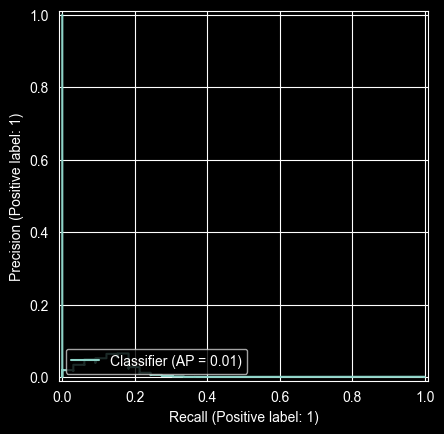

In [5]:
results = evaluate_model(y_test, scores, threshold=cross_val_scores["mean_threshold"], result_path=result_path)
print(results)

In [6]:
import pandas as pd
import os
df = pd.DataFrame(scores, columns=["score"])
scores_path = os.path.join(result_path, "scores.csv")
df.to_csv(scores_path, index=False)